In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

#Importação das bibliotecas

In [ ]:
df = pd.read_csv('web_page_phishing.csv')
display(df)

,url_length,n_dots,n_hypens,n_underline,n_slash,n_questionmark,n_equal,n_at,n_and,n_exclamation,n_space,n_tilde,n_comma,n_plus,n_asterisk,n_hastag,n_dollar,n_percent,n_redirection,phishing
0,37,3,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1,77,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1
2,126,4,1,2,0,1,3,0,2,0,0,0,0,0,0,0,0,0,1,1
3,18,2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0
4,55,2,2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
100072,23,3,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
100073,34,2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,2,0
100074,70,2,1,0,5,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1
100075,28,2,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1


**Preparação e criação da coluna 'unique_id'**

In [3]:
df.insert(0, 'unique_id', range(1, len(df) + 1))
print('Coluna unique_id criada com sucesso.')
display(df)

Coluna unique_id criada com sucesso.


,unique_id,url_length,n_dots,n_hypens,n_underline,n_slash,n_questionmark,n_equal,n_at,n_and,...,n_space,n_tilde,n_comma,n_plus,n_asterisk,n_hastag,n_dollar,n_percent,n_redirection,phishing
0,1,37,3,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,2,77,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,1
2,3,126,4,1,2,0,1,3,0,2,...,0,0,0,0,0,0,0,0,1,1
3,4,18,2,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0
4,5,55,2,2,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
100072,100073,23,3,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
100073,100074,34,2,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,2,0
100074,100075,70,2,1,0,5,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
100075,100076,28,2,0,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1


**Criação da tabela 'web_page_fishing'**

In [4]:
web_page_fishing = df[[
    'unique_id',
    'url_length',
    'n_redirection',
    'phishing'
]]
display(web_page_fishing)

,unique_id,url_length,n_redirection,phishing
0,1,37,0,0
1,2,77,1,1
2,3,126,1,1
3,4,18,1,0
4,5,55,1,0
...,...,...,...,...
100072,100073,23,0,0
100073,100074,34,2,0
100074,100075,70,0,1
100075,100076,28,0,1


**Criação da tabela 'phishing_dataset'**

In [6]:
phishing_dataset = df[[
    'unique_id', 'n_dots', 'n_hypens', 'n_underline', 'n_slash', 
     'n_questionmark', 'n_equal', 'n_at', 'n_and', 'n_exclamation', 
     'n_space', 'n_tilde', 'n_comma', 'n_plus', 'n_asterisk', 
    'n_hastag', 'n_dollar', 'n_percent'
]]
display(phishing_dataset)

,unique_id,n_dots,n_hypens,n_underline,n_slash,n_questionmark,n_equal,n_at,n_and,n_exclamation,n_space,n_tilde,n_comma,n_plus,n_asterisk,n_hastag,n_dollar,n_percent
0,1,3,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1,2,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2,3,4,1,2,0,1,3,0,2,0,0,0,0,0,0,0,0,0
3,4,2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
4,5,2,2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
100072,100073,3,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
100073,100074,2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
100074,100075,2,1,0,5,0,0,0,0,0,0,0,0,0,0,0,0,0
100075,100076,2,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0


Prática do SQL:
Que código SQL você escreveria para consultar todos os dados contidos no conjunto de dados fornecido?
R: INNER JOIN

In [ ]:
import sqlite3

#1. Criação do banco de dados
conn = sqlite3.connect('projeto_phishing.db')

#2. Envio dos DataFrames para dentro desse banco como tabelas
web_page_fishing.to_sql('web_page_fishing', conn, index=False)
phishing_dataset.to_sql('phishing_dataset', conn, index=False)

#3. Query em SQL
query = """
    SELECT *
    FROM web_page_fishing
    INNER JOIN phishing_dataset
    WHERE web_page_fishing.unique_id = phishing_dataset.unique_id
"""

#4. Carregando o resultado da consulta de volta para um DataFrame
resultado_query = pd.read_sql_query(query, conn)

In [20]:
display(resultado_query)




,unique_id,url_length,n_redirection,phishing,unique_id,n_dots,n_hypens,n_underline,n_slash,n_questionmark,...,n_and,n_exclamation,n_space,n_tilde,n_comma,n_plus,n_asterisk,n_hastag,n_dollar,n_percent
0,1,37,0,0,1,3,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,2,77,1,1,2,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,3,126,1,1,3,4,1,2,0,1,...,2,0,0,0,0,0,0,0,0,0
3,4,18,1,0,4,2,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,5,55,1,0,5,2,2,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
100072,100073,23,0,0,100073,3,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
100073,100074,34,2,0,100074,2,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
100074,100075,70,0,1,100075,2,1,0,5,0,...,0,0,0,0,0,0,0,0,0,0
100075,100076,28,0,1,100076,2,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0


Análise de correlação

In [23]:
correlacoes = resultado_query.corr('pearson')['phishing'].sort_values(ascending=False)

print('Campos com maior correlação POSITIVA: ')
print(correlacoes.head(6))

print('Campos com MENOR correlação:')
print(correlacoes.tail(6))

Campos com maior correlação POSITIVA: 
phishing      1.000000
n_slash       0.611472
url_length    0.430125
n_equal       0.260462
n_and         0.189173
n_dots        0.181884
Name: phishing, dtype: float64
Campos com MENOR correlação:
n_space          0.014757
n_hastag         0.010257
n_plus           0.006619
n_redirection   -0.050822
unique_id       -0.054807
unique_id       -0.054807
Name: phishing, dtype: float64


Análise de tendências centrais

In [26]:

valores_extremos = resultado_query.groupby('phishing')['url_length'].agg(['max', 'min'])
print(valores_extremos)

print(resultado_query.groupby('phishing')['url_length'].describe())

           max  min
phishing           
0          557    4
1         4165    5
            count       mean        std  min   25%   50%   75%     max
phishing                                                              
0         63715.0  23.589971  16.136071  4.0  16.0  20.0  25.0   557.0
1         36362.0  66.491117  68.598742  5.0  33.0  48.0  74.0  4165.0


Você diria que o número de redirecionamentos é um forte indicador de se a URL é phishing ou não? Por que sim ou por que não? Que métricas você tem para apoiar sua resposta?


In [29]:
corr = resultado_query['phishing'].corr(resultado_query['n_redirection'])
print(f'O nível de correlação entre o número de redirecionamentos e phishing é igual a {corr}. ')
print('O valor observado indica que a correlação é quase nula.')

O nível de correlação entre o número de redirecionamentos e phishing é igual a -0.050821867234429545. 
O valor observado indica que a correlação é quase nula.


In [31]:
descricao = resultado_query.groupby('phishing')['n_redirection'].describe()
print(descricao)

            count      mean       std  min  25%  50%  75%   max
phishing                                                       
0         63715.0  0.391305  0.803827 -1.0  0.0  0.0  1.0  12.0
1         36362.0  0.309361  0.720219 -1.0  0.0  0.0  1.0  17.0


Análise de outliers com boxplot

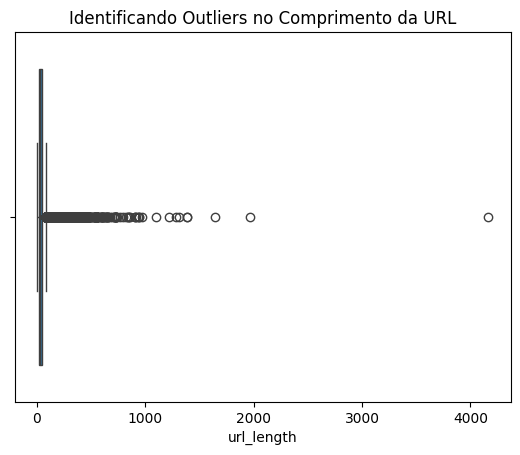

In [33]:
sns.boxplot(x=resultado_query['url_length'])
plt.title('Identificando Outliers no Comprimento da URL')
plt.show()

In [34]:
p99 = resultado_query['url_length'].quantile(0.99)
print(f"99% das URLs têm comprimento até: {p99}")

99% das URLs têm comprimento até: 238.0


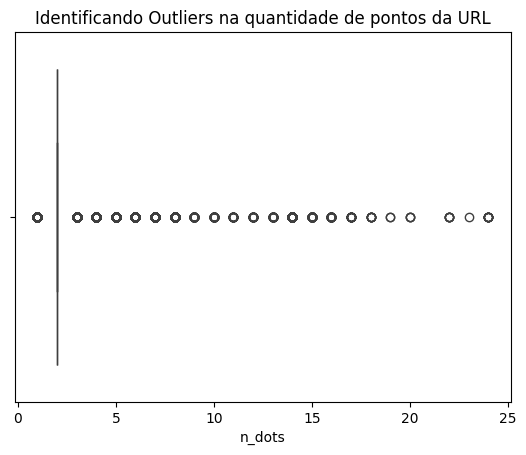

In [35]:
sns.boxplot(x=resultado_query['n_dots'])
plt.title('Identificando Outliers na quantidade de pontos da URL')
plt.show()